In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import pandas as pd
import numpy as np

In [2]:
import sys
sys.path.append('../src')

In [3]:
from transformers.transformers_l import DropColumnsTransformer, CityBasedImputer, CityMapTransformer, RollingAverageTransformer

In [18]:
X = pd.read_csv('../src/data/raw/dengue_features_train.csv')
y = pd.read_csv('../src/data/raw/dengue_labels_train.csv')
y = y[['total_cases']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

lagging_features = [
    'station_avg_temp_c',
    'reanalysis_min_air_temp_k',
    'ndvi_ne',
    'reanalysis_specific_humidity_g_per_kg',
    'station_diur_temp_rng_c',
    'ndvi_sw',
    'reanalysis_max_air_temp_k',
    'reanalysis_avg_temp_k',
    'reanalysis_relative_humidity_percent',
    'station_avg_temp_c',
    'reanalysis_precip_amt_kg_per_m2'    
]

preserved_features = [
    'city',
    'year',
    'weekofyear',
]

features_to_drop = list(set(X.columns) - set(lagging_features) - set(preserved_features))

# 1. Create a preprocessing pipeline without the model
preprocessing_pipeline = Pipeline(steps=[
    ('drop_columns', DropColumnsTransformer(columns_to_drop=features_to_drop)),
    ('city_encoder', CityMapTransformer()),
    ('imputer', CityBasedImputer(city_column='city')),
    ('rolling_avg', RollingAverageTransformer(
        columns=lagging_features, 
        window=3)), 
    ('drop_rolling_columns', DropColumnsTransformer(columns_to_drop=lagging_features)),
    ("scaler", StandardScaler())
])

# 2. Define your model separately
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_leaf=1,
    random_state=0
)

# 3. Fit the preprocessing pipeline and transform the data
preprocessing_pipeline.fit(X_train)
X_train_processed = preprocessing_pipeline.transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# 4. Fit your model on preprocessed data
model.fit(X_train_processed, y_train)

# 5. Make predictions on the processed test data
y_pred = model.predict(X_test_processed)
print(mean_absolute_error(y_test, y_pred))

# 6. For competition data, transform it first
X_test_competition = pd.read_csv('../src/data/raw/dengue_features_test.csv')
X_test_competition_processed = preprocessing_pipeline.transform(X_test_competition)

# 7. For final model, use all data
X_processed = preprocessing_pipeline.fit_transform(X)
model.fit(X_processed, y)
predictions = model.predict(X_test_competition_processed)

predictions_df = pd.DataFrame({
    'city': X_test_competition['city'],
    'year': X_test_competition['year'],
    'weekofyear': X_test_competition['weekofyear'],
    'total_cases': predictions
})

predictions_df.to_csv('../src/data/predictions/baseline_prediction.csv', index=False)

/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


12.896369863013698


/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [7]:
!pip install cloudpickle

In [19]:
import os
import joblib

# Create the models directory if it doesn't exist
os.makedirs('../src/models', exist_ok=True)

# Save the trained model to a pickle file
joblib.dump(model, '../src/models/baseline_model.pkl')
print("Model saved successfully.")

Model saved successfully.


In [20]:
import joblib
impmodel = joblib.load('../src/models/baseline_model.pkl')


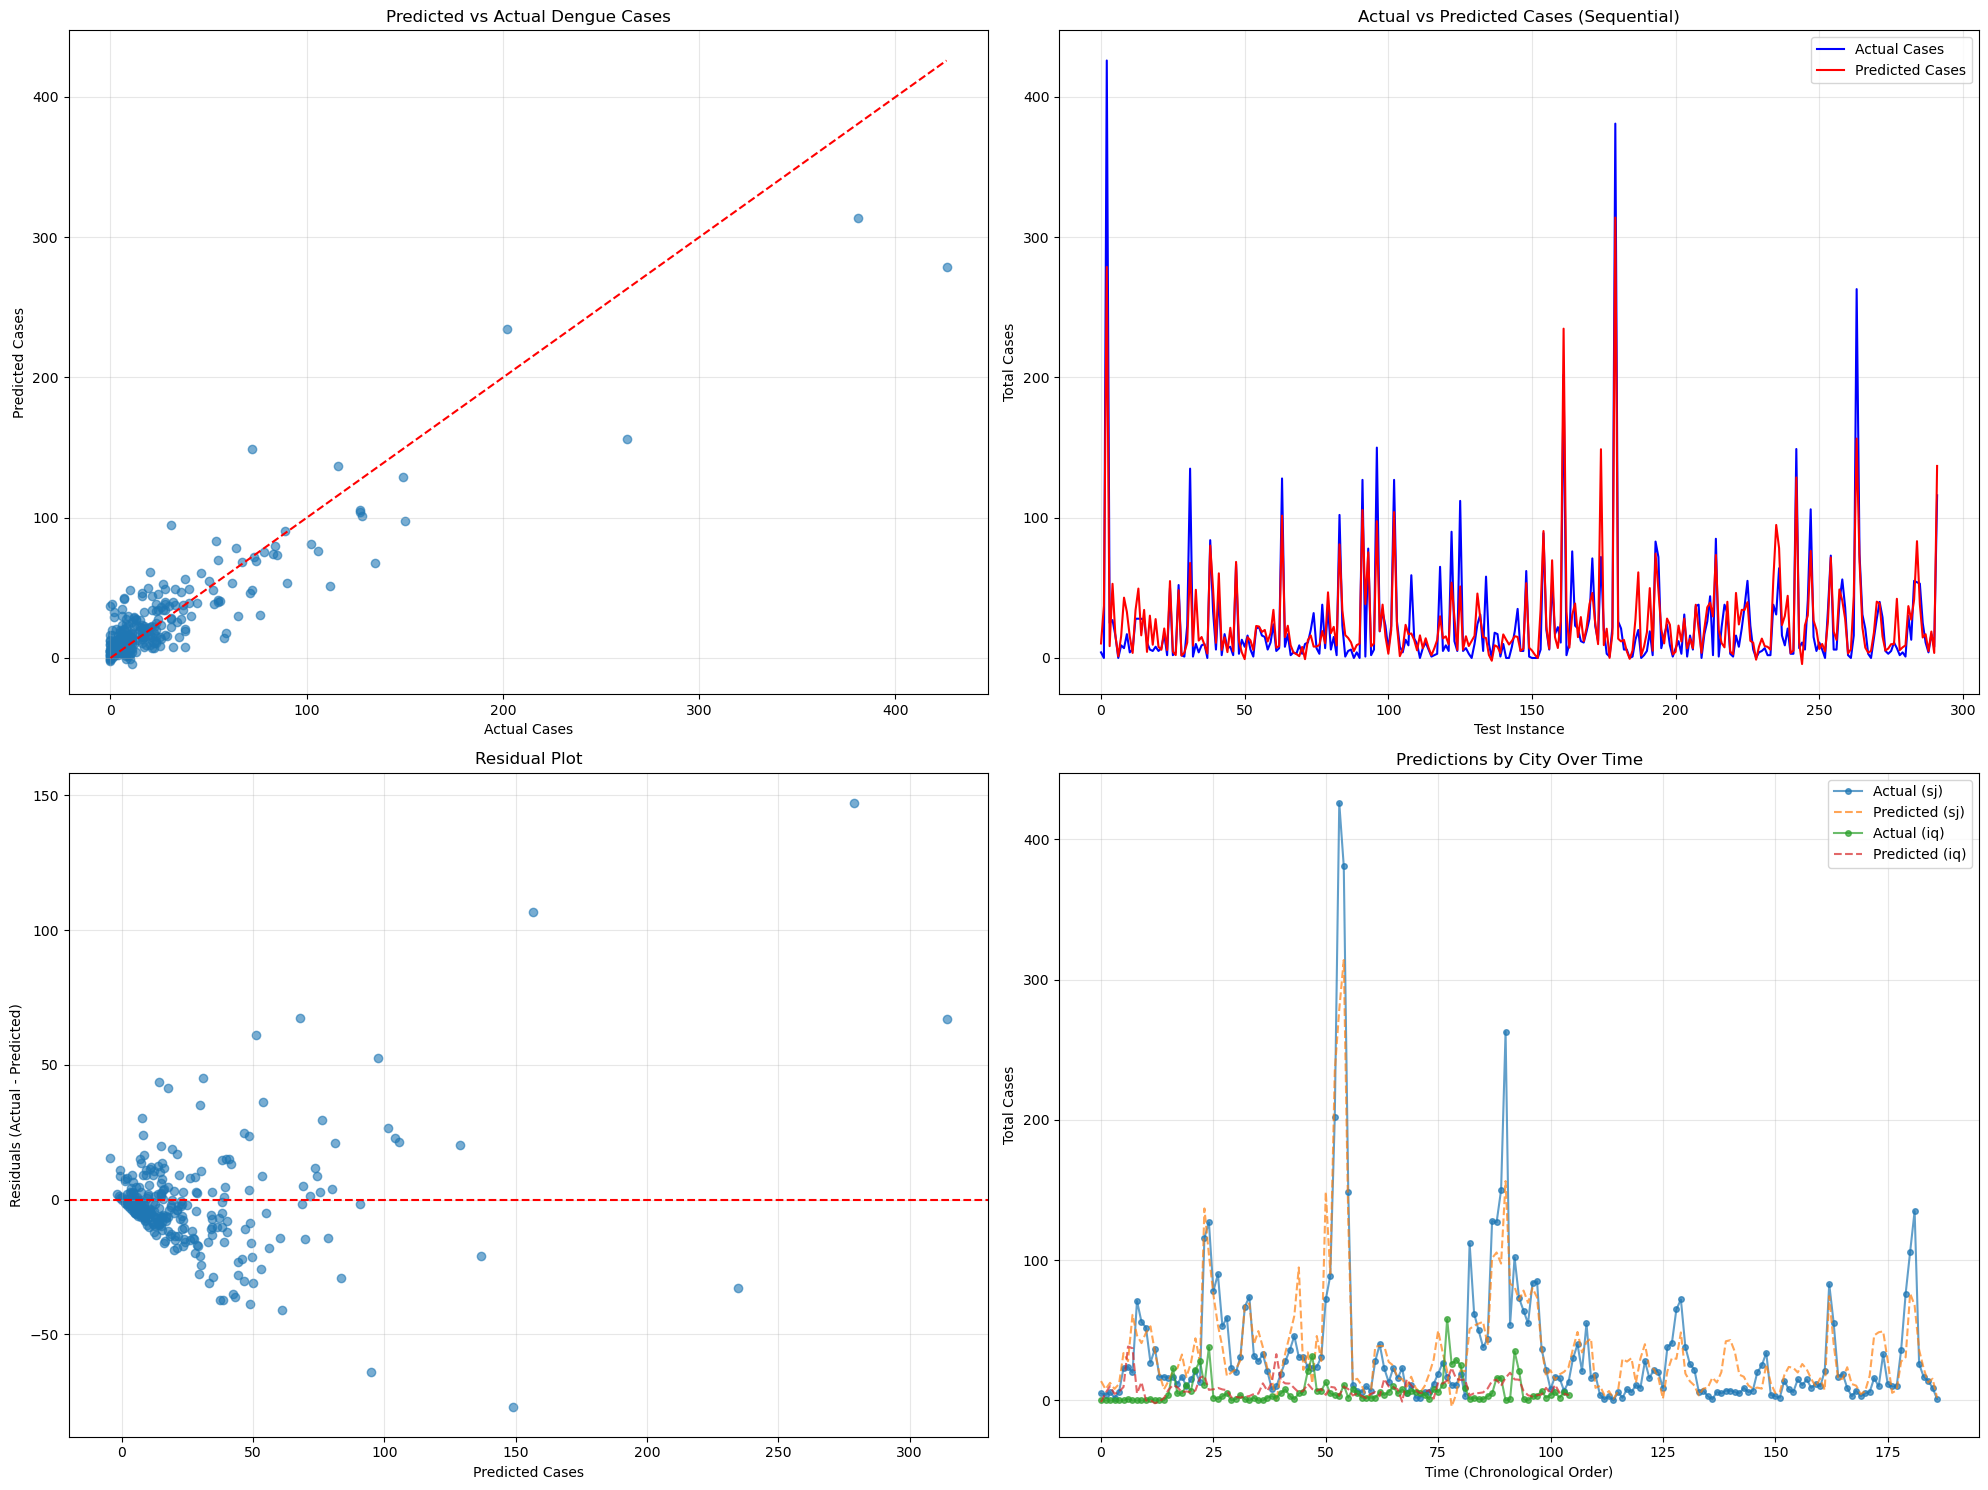

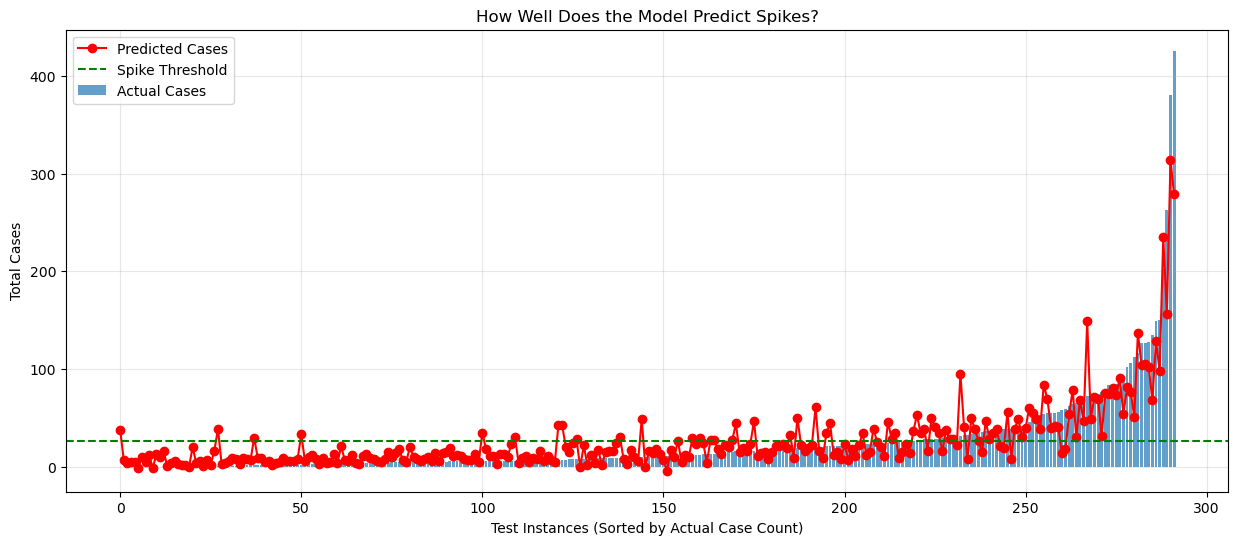

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with multiple subplots for comprehensive analysis
plt.figure(figsize=(20, 15))

# 1. Standard comparison plot
plt.subplot(2, 2, 1)
plt.scatter(y_test['total_cases'], y_pred, alpha=0.6)
plt.plot([0, max(y_test['total_cases'])], [0, max(y_test['total_cases'])], 'r--')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases') 
plt.title('Predicted vs Actual Dengue Cases')
plt.grid(alpha=0.3)

# 2. Timeline view - shows how predictions track actual values over time
plt.subplot(2, 2, 2)
indices = range(len(y_test))
plt.plot(indices, y_test['total_cases'], 'b-', label='Actual Cases')
plt.plot(indices, y_pred, 'r-', label='Predicted Cases')
plt.xlabel('Test Instance')
plt.ylabel('Total Cases')
plt.title('Actual vs Predicted Cases (Sequential)')
plt.legend()
plt.grid(alpha=0.3)

# 3. Residual plot - shows prediction errors
plt.subplot(2, 2, 3)
residuals = y_test['total_cases'].values - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Cases')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(alpha=0.3)

# 4. City-specific time series
plt.subplot(2, 2, 4)

# Create a dataframe with test data and predictions
results_df = pd.DataFrame({
    'city': X_test['city'],
    'year': X_test['year'],
    'weekofyear': X_test['weekofyear'],
    'actual': y_test['total_cases'].values,
    'predicted': y_pred
})

# Plot separately by city
for city in results_df['city'].unique():
    city_data = results_df[results_df['city'] == city]
    city_data = city_data.sort_values(['year', 'weekofyear'])
    
    plt.plot(range(len(city_data)), 
             city_data['actual'], 
             'o-', 
             label=f'Actual ({city})',
             alpha=0.7,
             markersize=4)
    
    plt.plot(range(len(city_data)), 
             city_data['predicted'], 
             '--', 
             label=f'Predicted ({city})',
             alpha=0.7)

plt.xlabel('Time (Chronological Order)')
plt.ylabel('Total Cases')
plt.title('Predictions by City Over Time')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# An additional visualization focusing on spikes
plt.figure(figsize=(15, 6))
spike_threshold = np.percentile(y_test['total_cases'], 75)  # Define spikes as top 25%

# Sort by actual case count to see the pattern of predictions on high case counts
sorted_indices = np.argsort(y_test['total_cases'].values)
sorted_actual = y_test['total_cases'].values[sorted_indices]
sorted_predicted = y_pred[sorted_indices]

plt.bar(range(len(sorted_actual)), sorted_actual, alpha=0.7, label='Actual Cases')
plt.plot(range(len(sorted_predicted)), sorted_predicted, 'ro-', label='Predicted Cases')

plt.axhline(y=spike_threshold, color='g', linestyle='--', label='Spike Threshold')
plt.xlabel('Test Instances (Sorted by Actual Case Count)')
plt.ylabel('Total Cases')
plt.title('How Well Does the Model Predict Spikes?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()